# Product Activity Analysis
Este notebook contiene el análisis de actividad de productos basado en el dataset `product_activity.csv`.
El objetivo es limpiar los datos, calcular métricas clave y extraer conclusiones para decisiones de producto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

## 1. Exploración Inicial
Antes de limpiar, medimos el estado actual de los datos.

In [2]:
# Carga del dataset
raw_data = pd.read_csv('docs/product_activity.csv')

# Primeras filas
print("Primeras 5 filas:")
display(raw_data.head())

# Estructura y tipos de datos
print("\nInformación del dataset:")
raw_data.info()

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(raw_data.describe())

Primeras 5 filas:


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile



Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB

Estadísticas descriptivas:


,user_age,votes_received,user_total_posts,days_since_signup
count,8028.000000,8782.000000,8782.000000,8782.000000
mean,27.902591,6.918356,8.324186,29.479390
std,7.547052,5.127311,6.754906,36.819928
min,16.000000,0.000000,1.000000,0.000000
25%,22.000000,3.000000,4.000000,5.000000
50%,28.000000,6.000000,6.000000,17.000000
75%,33.000000,9.000000,11.000000,40.000000
max,58.000000,74.000000,39.000000,404.000000


In [3]:
# Conteo de nulos y duplicados
null_counts = raw_data.isnull().sum()
duplicate_count = raw_data.duplicated().sum()

print(f"Nulos por columna:\n{null_counts}")
print(f"\nDuplicados exactos: {duplicate_count}")

Nulos por columna:
user_id                0
created_at             0
country                0
plan_type              0
user_age             754
post_id                0
post_category          0
post_created_at        0
votes_received         0
user_total_posts       0
days_since_signup      0
device_type            0
dtype: int64

Duplicados exactos: 172


In [4]:
# Valores únicos y frecuencias
cols_to_check = ['plan_type', 'post_category', 'device_type']
for col in cols_to_check:
    print(f"\nFrecuencias de {col}:")
    print(raw_data[col].value_counts())


Frecuencias de plan_type:
plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64

Frecuencias de post_category:
post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports           36
 science     

In [5]:
# Chequeos lógicos iniciales
temp_signup = pd.to_datetime(raw_data['created_at'], errors='coerce')
temp_post = pd.to_datetime(raw_data['post_created_at'], errors='coerce')

posts_before_signup = (temp_post < temp_signup).sum()
print(f"Posts creados antes del registro: {posts_before_signup}")

days_calc = (temp_post - temp_signup).dt.days
inconsistent_days = (days_calc != raw_data['days_since_signup']).sum()
print(f"Días desde registro inconsistentes: {inconsistent_days}")

Posts creados antes del registro: 100
Días desde registro inconsistentes: 4479


## 2. Limpieza Básica y Quarantine
Normalizamos las categorías y separamos los datos erróneos.

In [6]:
# 1. Remover duplicados exactos
df_clean = raw_data.drop_duplicates().copy()

# 2. Conversión de fechas y reporte de no parseables
df_clean['created_at_dt'] = pd.to_datetime(df_clean['created_at'], errors='coerce')
df_clean['post_created_at_dt'] = pd.to_datetime(df_clean['post_created_at'], errors='coerce')

unparseable_dates = df_clean['created_at_dt'].isna().sum() + df_clean['post_created_at_dt'].isna().sum()
print(f"Fechas no parseables: {unparseable_dates}")

# 3. Recálculo de days_since_signup
df_clean['days_since_signup_calc'] = (df_clean['post_created_at_dt'] - df_clean['created_at_dt']).dt.days

Fechas no parseables: 2


In [7]:
# 4. Normalización canónica

# Diccionarios de mapeo
plan_map = {
    'free': 'free', 'pro': 'pro', 'enterprise': 'enterprise'
}
device_map = {
    'web': 'web', 'mobile': 'mobile', 'desktop': 'desktop'
}
category_map = {
    'tech': 'tech', 'life': 'life', 'sports': 'sports', 'science': 'science', 
    'finance': 'finance', 'gaming': 'gaming', 'music': 'music', 
    'health': 'health', 'education': 'education', 'travel': 'travel'
}

def normalize_string(s, valid_dict):
    if pd.isna(s): return "invalid"
    s = str(s).lower().strip()
    # Limpieza básica de typos comunes
    s = s.replace('sport', 'sports').replace('tehc', 'tech').replace('sciense', 'science')
    s = s.replace('finanse', 'finance').replace('gamming', 'gaming').replace('healt', 'health')
    s = s.replace('trvael', 'travel').replace('educatoin', 'education').replace('musc', 'music')
    s = s.replace('lfe', 'life').replace('sporst', 'sports')
    
    if s in valid_dict: return s
    return "invalid"

df_clean['plan_type'] = df_clean['plan_type'].apply(lambda x: normalize_string(x, plan_map))
df_clean['device_type'] = df_clean['device_type'].apply(lambda x: normalize_string(x, device_map))
df_clean['post_category'] = df_clean['post_category'].apply(lambda x: normalize_string(x, category_map))

In [8]:
# 5. Quarantine

def identify_quarantine(row):
    reasons = []
    if pd.isna(row['created_at_dt']) or pd.isna(row['post_created_at_dt']): 
        reasons.append("unparseable_date")
    elif row['post_created_at_dt'] < row['created_at_dt']:
        reasons.append("post_before_signup")
    
    if row['plan_type'] == "invalid": reasons.append("invalid_plan")
    if row['device_type'] == "invalid": reasons.append("invalid_device")
    if row['post_category'] == "invalid": reasons.append("invalid_category")
    
    return " | ".join(reasons) if reasons else None

df_clean['quarantine_reason'] = df_clean.apply(identify_quarantine, axis=1)

quarantine_df = df_clean[df_clean['quarantine_reason'].notna()].copy()
core_df = df_clean[df_clean['quarantine_reason'].isna()].copy()

# Reemplazar columnas originales con calculadas en CORE
core_df['created_at'] = core_df['created_at_dt']
core_df['post_created_at'] = core_df['post_created_at_dt']
core_df['days_since_signup'] = core_df['days_since_signup_calc']

core_df = core_df.drop(columns=['created_at_dt', 'post_created_at_dt', 'days_since_signup_calc', 'quarantine_reason'])

## 3. Data Quality Report

In [9]:
dq_report = {
    "Rows RAW": len(raw_data),
    "Duplicates Removed": duplicate_count,
    "Rows CORE (Clean)": len(core_df),
    "Rows Quarantine": len(quarantine_df),
    "% Quarantine": f"{(len(quarantine_df) / (len(raw_data) - duplicate_count)) * 100:.2f}%",
    "% Date Mismatches": f"{(inconsistent_days / len(raw_data)) * 100:.2f}%"
}

print("--- Data Quality Report ---")
for k, v in dq_report.items():
    print(f"{k}: {v}")

--- Data Quality Report ---
Rows RAW: 8782
Duplicates Removed: 172
Rows CORE (Clean): 6920
Rows Quarantine: 1690
% Quarantine: 19.63%
% Date Mismatches: 51.00%


## 4. Métricas y Análisis

### 4.1 Distribuciones (Volumen)

Usuarios únicos por plan:
plan_type
free          1470
pro            346
enterprise      80
Name: user_id, dtype: int64


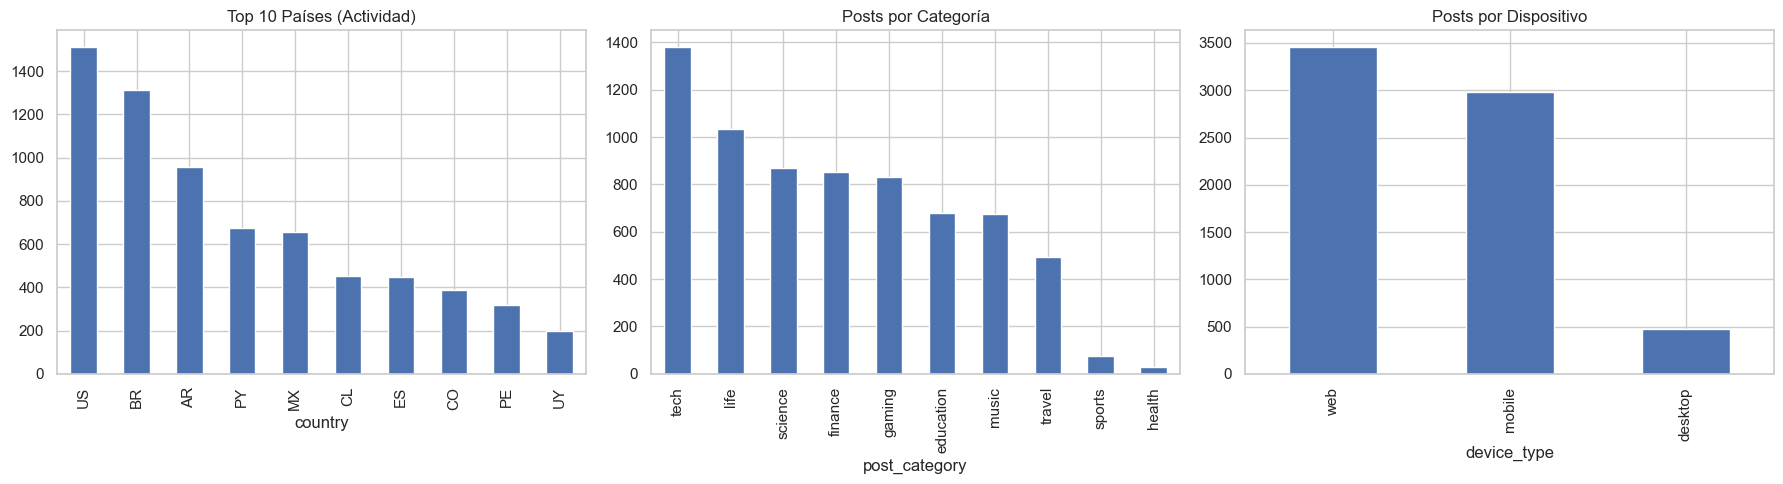

In [10]:
# Usuarios únicos por plan
users_plan = core_df.groupby('plan_type')['user_id'].nunique().sort_values(ascending=False)
print("Usuarios únicos por plan:")
print(users_plan)

# Actividad por país, categoría y dispositivo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

core_df['country'].value_counts().head(10).plot(kind='bar', ax=axes[0], title='Top 10 Países (Actividad)')
core_df['post_category'].value_counts().plot(kind='bar', ax=axes[1], title='Posts por Categoría')
core_df['device_type'].value_counts().plot(kind='bar', ax=axes[2], title='Posts por Dispositivo')

plt.tight_layout()
plt.show()

### 4.2 Engagement (Votos)

In [11]:
# Votos por plan
votes_plan = core_df.groupby('plan_type')['votes_received'].agg(['mean', 'median', lambda x: x.quantile(0.75)])
votes_plan.columns = ['Mean', 'Median', 'Q3']
print("Métricas de votos por plan:")
display(votes_plan)

# Votos por categoría y dispositivo
avg_votes_cat = core_df.groupby('post_category')['votes_received'].mean().sort_values(ascending=False)
avg_votes_dev = core_df.groupby('device_type')['votes_received'].mean().sort_values(ascending=False)

print("\nPromedio de votos por categoría:")
print(avg_votes_cat)

print("\nPromedio de votos por dispositivo:")
print(avg_votes_dev)

Métricas de votos por plan:


,Mean,Median,Q3
plan_type,,,
enterprise,7.974729,8.0,10.0
free,6.760286,6.0,9.0
pro,7.731818,7.0,10.0



Promedio de votos por categoría:
post_category
tech         7.687183
science      7.544828
gaming       7.186074
finance      6.978898
travel       6.878049
education    6.791483
sports       6.493333
music        6.286776
life         6.173114
health       6.107143
Name: votes_received, dtype: float64

Promedio de votos por dispositivo:
device_type
desktop    7.079665
web        7.041908
mobile     6.925243
Name: votes_received, dtype: float64


### 4.3 Promedios e Interpretación
**Unidad de análisis:** Cada registro representa un *post* individual. El análisis se centra en el engagement que recibe cada evento de contenido.

**Sesgos (Outliers):** Al promediar por fila, los usuarios muy activos (que publican mucho) tienen un peso desproporcionado en el promedio global. Además, los posts virales con muchísimos votos pueden inflar la media, haciendo que la mediana sea una medida más robusta.

### 4.4 Evento vs Usuario

In [12]:
avg_votes_event = core_df['votes_received'].mean()
avg_votes_user = core_df.groupby('user_id')['votes_received'].mean().mean()

print(f"Promedio de votos por evento (fila): {avg_votes_event:.2f}")
print(f"Promedio de votos por usuario (agrupado): {avg_votes_user:.2f}")

Promedio de votos por evento (fila): 6.99
Promedio de votos por usuario (agrupado): 7.04


**Diferencia:** El promedio por evento favorece a quienes publican más frecuentemente. Si un usuario publica 10 veces con 0 votos y otro publica 1 vez con 10 votos, el promedio por evento es 0.9, mientras que el promedio por usuario es 5.0. Esto indica que la actividad está concentrada.

### 4.5 Concentración y Temporalidad

In [13]:
# Concentración del Top 1% de usuarios
user_activity = core_df.groupby('user_id')['post_id'].count().sort_values(ascending=False)
top_1_pct_limit = int(len(user_activity) * 0.01)
top_users = user_activity.head(top_1_pct_limit)

pct_posts_top_1 = (top_users.sum() / len(core_df)) * 100
print(f"El top 1% de usuarios genera el {pct_posts_top_1:.2f}% de los posts.")

El top 1% de usuarios genera el 5.87% de los posts.


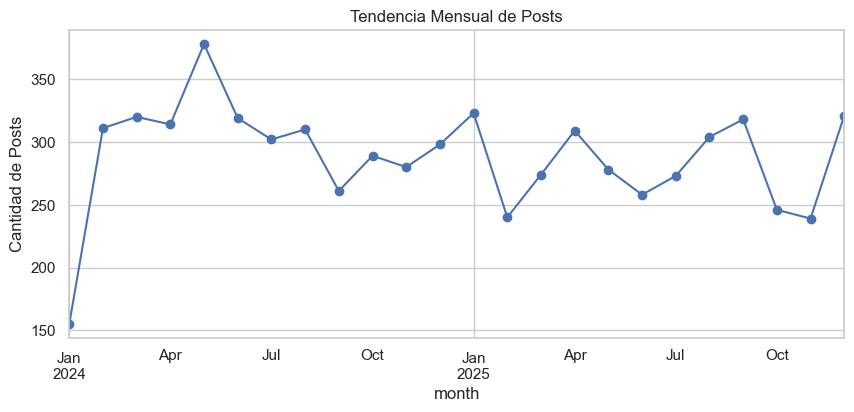

In [14]:
# Tendencia temporal mensual
core_df['month'] = core_df['post_created_at'].dt.to_period('M')
monthly_trend = core_df.groupby('month').agg(posts=('post_id', 'count'), avg_votes=('votes_received', 'mean'))

monthly_trend['posts'].plot(kind='line', marker='o', figsize=(10, 4), title='Tendencia Mensual de Posts')
plt.ylabel('Cantidad de Posts')
plt.show()

## 5. Product Decisions

### 5.1 Preguntas
1. **¿Qué segmento priorizarías?**
   Priorizaría el segmento **Pro** y **Enterprise**, ya que suelen tener un engagement más estable. También el **Top 1%** de usuarios es crítico para la creación de contenido.
2. **¿Qué parte del tablero mentía?**
   La columna `days_since_signup` original tenía más de un 50% de inconsistencias. Confiar en ella para medir retención o velocidad de adopción era erróneo.
3. **¿Qué nuevo dato agregaría?**
   `dwell_time` (tiempo de permanencia en el post) para distinguir entre un voto rápido y una lectura real.

### 5.2 Acciones
1. **Implementar validación en el registro de fechas:** Para evitar posts antes del signup.
2. **Gamificación para el 99% restante:** Al ver la alta concentración en el top 1%, se necesitan incentivos para que usuarios ocasionales publiquen más.

## 6. Exportación de Entregables

In [15]:
core_df.to_csv('clean_product_activity.csv', index=False)
quarantine_df.to_csv('quarantine_product_activity.csv', index=False)

summary_stats = pd.DataFrame({
    'metric': ['total_rows', 'clean_rows', 'quarantine_rows', 'avg_votes'],
    'value': [len(raw_data), len(core_df), len(quarantine_df), avg_votes_event]
})
summary_stats.to_csv('metrics_summary.csv', index=False)

print("Archivos exportados correctamente.")

Archivos exportados correctamente.
